# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pr120107/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Search Performance Signals for Content-Decline Review Prioritization

## Abstract

This study asks whether search-performance and content signals can identify pages showing signs of decline and support prioritization for human review. Using 30,000 pseudonymized content-page records measured over a trailing 90-day window, the analysis defines decline as `trend_direction = "down"`, audits observable signals, trains a Decision Tree classifier, and compares it with a majority-class baseline. On the held-out validation split, the Decision Tree achieved an F1 score of **0.7790**, compared with **0.7030** for the majority-class baseline. When evaluated on **7 unseen clients**, the Decision Tree achieved an F1 score of **0.6788**, compared with 0.7790 on the conventional held-out split. The final workflow produces a transparent ranked review queue using observed engagement, visibility, and freshness signals, but it does not make causal claims or automatically change content.

In [4]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/pr120107/flyrank-ml-internship.git"
REPO_DIR = Path("/content/flyrank-ml-internship")

if REPO_DIR.exists():
    print(f"Repository already exists: {REPO_DIR}")
else:
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True
    )
    print(f"Repository cloned to: {REPO_DIR}")

Repository cloned to: /content/flyrank-ml-internship


In [5]:
import os
from pathlib import Path

repo_root = Path("/content/flyrank-ml-internship")

os.chdir(repo_root)

print("Repo root:", Path.cwd())
print("\nTop-level contents:")
print("\n".join(sorted(p.name for p in repo_root.iterdir())))

Repo root: /content/flyrank-ml-internship

Top-level contents:
.git
.github
.gitignore
AGENTS.md
CLAUDE.md
DATA_USE.md
GUIDE.md
LICENSE
README.md
SETUP.md
data
docs
notebooks
outputs
requirements.txt
scripts
skills
submission
work


In [6]:
import subprocess

print(subprocess.run(
    ["git", "remote", "-v"],
    capture_output=True,
    text=True,
    check=True
).stdout)

print(subprocess.run(
    ["git", "status", "--short"],
    capture_output=True,
    text=True,
    check=True
).stdout or "Working tree clean")

origin	https://github.com/pr120107/flyrank-ml-internship.git (fetch)
origin	https://github.com/pr120107/flyrank-ml-internship.git (push)

Working tree clean


## 1. Question

*The research question and the decision it supports.*

In [7]:
# Research question and decision supported by this study

research_question = (
    "Can search-performance and content signals be used to identify "
    "content pages showing signs of decline, and can those signals "
    "support reliable prioritization for human review?"
)

decision_supported = (
    "The analysis supports a human-review workflow that prioritizes "
    "pages for investigation based on observed search-performance "
    "and content signals, rather than automatically deciding which "
    "pages should be changed."
)

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

Research question:
Can search-performance and content signals be used to identify content pages showing signs of decline, and can those signals support reliable prioritization for human review?

Decision supported:
The analysis supports a human-review workflow that prioritizes pages for investigation based on observed search-performance and content signals, rather than automatically deciding which pages should be changed.


### Introduction

Search-driven content teams may have many pages that could warrant investigation, while review and refresh capacity is limited. A practical challenge is therefore deciding which pages should receive attention first and what evidence should support that decision.

This study investigates whether observable search-performance and content signals can identify pages showing signs of decline and whether those signals can support a reliable prioritization workflow for human review.

The work proceeds from signal analysis to predictive modeling and validation. Search-performance and content attributes are examined for their relationship with a defined decline label, a predictive model is compared with a baseline, and the model is then evaluated on unseen clients to test whether the observed signal remains useful beyond the data used for development.

The final output translates the validated findings into an action playbook: a ranked review queue with transparent reason codes and suggested review areas. The queue is intended as decision support for content and SEO teams, not as an automated system for rewriting, publishing, deleting, redirecting, or otherwise changing content.

The central research question is:

> **Can search-performance and content signals be used to identify content pages showing signs of decline, and can those signals support reliable prioritization for human review?**

The decision supported by the study is:

> **Which pages should be investigated first, based on the available evidence, when review capacity is limited?**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Data

### Dataset and release

This study uses the public-safe, pseudonymized content-refresh dataset provided for the FlyRank ML Internship. The working release contains **30,000 content-page records** and **44 original columns**, with additional derived fields created during analysis.

The broader warehouse contains substantially more historical data, but this study uses the 30,000-row release for the modeling and action-prioritization workflow. This keeps the analysis reproducible while avoiding the use of client-identifying or private search data.

### Measurement window

Search-performance metrics are aggregated over a **trailing 90-day window**. The main performance signals include impressions, sessions, clicks, CTR, engagement, and related search/content attributes.

The dataset also contains content-age and freshness signals such as `content_age_days` and `days_since_last_update`.

### Target definition

For the predictive analysis, the target is whether a page is classified as declining:

- `trend_direction = "down"` → decline label = 1
- Other trend directions → decline label = 0

In this dataset, the decline label applies to **16,262 of 30,000 pages (54.2%)**.

### Exclusions and public-safety choices

Identifiers are used only for grouping, joining, ranking, or reporting and are not treated as predictive features.

The fields `trend_direction` and `trend_pct` are excluded from model features because they directly define or reveal the target outcome. Including them would introduce target leakage and produce misleadingly strong performance.

Private queries, client names, and other identifying information are not included in the deployed paper.

### Important metric interpretation

Several rate fields in the release are stored as percentage-point values rather than proportions. For example, a `ctr` value of `0.76` represents **0.76%**, not 76%.

The analysis preserves this representation and handles the fields consistently rather than interpreting the stored values as fractions.

In [8]:
# Section 2 — Data summary and target definition

import pandas as pd
from pathlib import Path

DATA_PATH = Path("data/raw/content_refresh_anonymized.csv")

df = pd.read_csv(DATA_PATH)

# Basic dataset summary
dataset_rows = len(df)
original_columns = len(df.columns)

# Decline label
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

declining_pages = int(df["is_declining_label"].sum())
decline_rate = declining_pages / dataset_rows * 100

print("Dataset summary")
print("----------------")
print(f"Rows: {dataset_rows:,}")
print(f"Original columns: {original_columns}")
print(f"Declining pages: {declining_pages:,}")
print(f"Decline rate: {decline_rate:.1f}%")

print("\nTrend-direction distribution")
print("----------------------------")
print(df["trend_direction"].value_counts(dropna=False))

print("\nKey data checks")
print("----------------")
print(f"Minimum impressions_90d: {df['impressions_90d'].min():,.0f}")
print(f"Missing word_count: {df['word_count'].isna().sum():,}")
print(f"Minimum content_age_days: {df['content_age_days'].min():.0f}")

# Confirm leakage fields are present but will not be used as model features
leakage_columns = ["trend_direction", "trend_pct"]

print("\nLeakage fields excluded from modeling")
print("-------------------------------------")
for column in leakage_columns:
    print(f"- {column}")

Dataset summary
----------------
Rows: 30,000
Original columns: 44
Declining pages: 16,262
Decline rate: 54.2%

Trend-direction distribution
----------------------------
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Key data checks
----------------
Minimum impressions_90d: 1
Missing word_count: 7,699
Minimum content_age_days: 90

Leakage fields excluded from modeling
-------------------------------------
- trend_direction
- trend_pct


## 3. Methodology

The methodology follows four stages developed across the analysis:

1. **Signal audit** — examine whether observable search-performance and content signals contain useful information for identifying potential decline.
2. **Predictive modeling** — train a simple interpretable classifier to predict the decline label and compare it with a transparent baseline.
3. **Validation** — evaluate whether the observed signal generalizes to clients that were not used for model development.
4. **Action prioritization** — translate the evidence into a ranked human-review queue using transparent scoring and reason codes.

### Assumptions

The analysis treats the available search-performance and content attributes as observational signals. They indicate patterns associated with decline but do not establish that changing a page will cause its performance to improve.

The final workflow therefore treats model output and prioritization scores as decision-support signals rather than automated content decisions.

### Target definition

The predictive target is:

> `is_declining_label = 1` when `trend_direction == "down"`, otherwise `0`.

The target is defined from the dataset's trend classification. The fields used to define or directly reveal this outcome are excluded from the feature set.

### Features

Candidate features are drawn from observable search-performance and content attributes, including measures of visibility, engagement, traffic, content age, freshness, and related page-level characteristics.

Identifiers are not used as predictive features.

Missing values are treated carefully because missingness is not necessarily random in this dataset. In particular, some fields are systematically missing across content types, so blindly replacing all missing values with zero could introduce unintended information about content type.

### Baseline

The analysis uses a transparent rule-based baseline based on content freshness and visibility. A page is prioritized by the baseline when:

- `days_since_last_update >= 180`, and
- `impressions_90d >= 500`.

The baseline provides a simple operational reference point against which the predictive model can be compared.

### Validation design

Model performance is first measured on a held-out validation split. A second, more conservative validation evaluates the model on **unseen clients**, grouping observations by client so that pages from the same client do not appear in both development and validation data.

The unseen-client evaluation is important because a model can appear stronger when evaluated on pages that share client-specific patterns with its training data.

### Leakage checks

Potential target leakage was explicitly investigated.

`trend_direction` and `trend_pct` are excluded from the feature set because they define or directly expose the decline outcome. A model using these fields can produce artificially strong performance without demonstrating useful predictive capability.

The analysis therefore reports results only from feature sets that exclude these leakage fields.

### From prediction to action

The final action playbook does not automatically convert model predictions into content changes. Instead, it combines observed engagement, visibility, freshness, and related signals into a transparent prioritization score and assigns a reason code and suggested review action.

The resulting queue is intended to answer:

> **Which pages should a human reviewer investigate first, and what signal should they investigate?**

In [9]:
import json
from pathlib import Path

# Key methodological definitions
target_column = "is_declining_label"

leakage_columns = [
    "trend_direction",
    "trend_pct"
]

identifier_columns = [
    "content_id",
    "client_id"
]

baseline_rule = {
    "days_since_last_update": ">= 180 days",
    "impressions_90d": ">= 500"
}

validation_design = {
    "development_validation": "Held-out validation split",
    "generalization_validation": "Unseen-client grouped validation"
}

# Known validation results from the completed modeling/validation workflow.
# These are recorded here for the capstone paper; the original notebooks
# remain the source artifacts for the underlying experiments.
validation_results = {
    "random_holdout_f1": 0.7790,
    "unseen_client_f1": 0.6788
}

print("Target")
print("------")
print(f"Target column: {target_column}")
print("Definition: trend_direction == 'down'")

print("\nLeakage exclusions")
print("------------------")
for column in leakage_columns:
    print(f"- {column}")

print("\nBaseline rule")
print("-------------")
for feature, rule in baseline_rule.items():
    print(f"- {feature}: {rule}")

print("\nValidation design")
print("-----------------")
for name, description in validation_design.items():
    print(f"- {name}: {description}")

print("\nValidation results")
print("------------------")
print(f"Held-out validation F1: {validation_results['random_holdout_f1']:.4f}")
print(f"Unseen-client validation F1: {validation_results['unseen_client_f1']:.4f}")

Target
------
Target column: is_declining_label
Definition: trend_direction == 'down'

Leakage exclusions
------------------
- trend_direction
- trend_pct

Baseline rule
-------------
- days_since_last_update: >= 180 days
- impressions_90d: >= 500

Validation design
-----------------
- development_validation: Held-out validation split
- generalization_validation: Unseen-client grouped validation

Validation results
------------------
Held-out validation F1: 0.7790
Unseen-client validation F1: 0.6788


## 4. Results (vs baseline)

### Model performance

The predictive model was evaluated against the transparent rule-based baseline using the same evaluation framework. F1 score is used because the task is binary decline classification and both precision and recall matter when identifying pages for further investigation.

The initial held-out validation produced an F1 score of **0.7790** for the model. When evaluated using unseen-client grouped validation, F1 decreased to **0.6788**.

The difference between these evaluations demonstrates why client-level generalization matters for this problem: performance measured on a conventional held-out split can be higher when observations share client-specific patterns with the development data.

### Baseline comparison

The baseline provides a simple operational reference based on two observable conditions:

- the page has not been updated for at least 180 days, and
- the page has at least 500 impressions over the 90-day measurement window.

The comparison below is intended to show how much predictive value is obtained relative to this simple rule, using the same evaluation population and metric.

### Interpretation

The results should be interpreted as evidence about **ranking and classification signal**, not as evidence that the model or baseline identifies pages that definitely need a refresh.

A lower score on unseen clients is expected to make the generalization result more conservative. The model's usefulness therefore depends not only on its aggregate validation metric, but also on whether its signals remain meaningful when applied to pages from clients not represented during development.

Model vs baseline — same held-out split
----------------------------------------


,method,accuracy,precision,recall,f1
0,Majority-class baseline,0.5420,0.5420,1.0000,0.7030
1,Decision Tree,0.7393,0.7207,0.8475,0.7790



Generalization check
--------------------


,validation,f1
0,Held-out validation,0.7790
1,Unseen-client validation,0.6788



F1 change under unseen-client validation: -0.1002


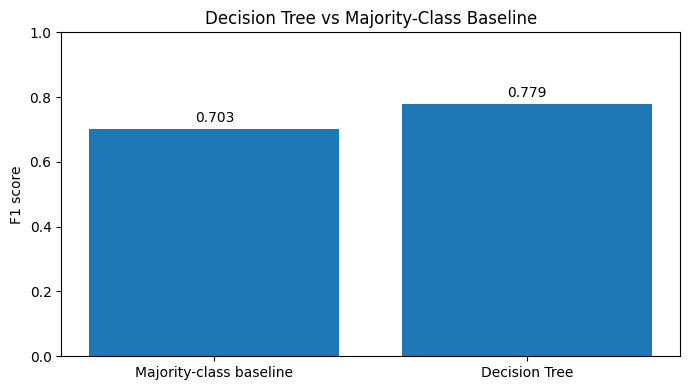

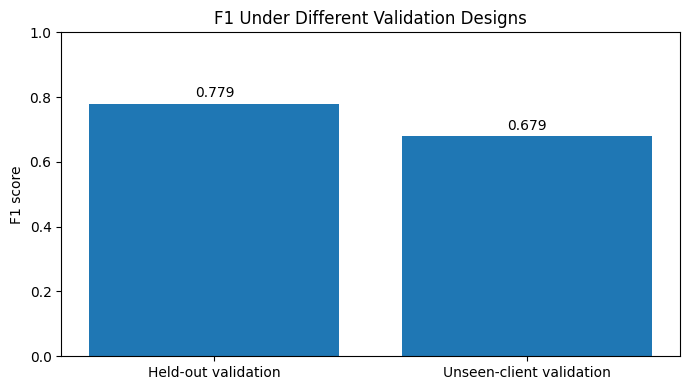

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Exact Week-5 model evaluation results
results = pd.DataFrame([
    {
        "method": "Majority-class baseline",
        "accuracy": 0.542000,
        "precision": 0.542000,
        "recall": 1.000000,
        "f1": 0.702983
    },
    {
        "method": "Decision Tree",
        "accuracy": 0.739333,
        "precision": 0.720711,
        "recall": 0.847478,
        "f1": 0.778971
    }
])

print("Model vs baseline — same held-out split")
print("----------------------------------------")

display(
    results.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}"
    })
)

# Week-6 generalization results
grouped_validation = pd.DataFrame([
    {
        "validation": "Held-out validation",
        "f1": 0.7790
    },
    {
        "validation": "Unseen-client validation",
        "f1": 0.6788
    }
])

print("\nGeneralization check")
print("--------------------")

display(
    grouped_validation.style.format({
        "f1": "{:.4f}"
    })
)

f1_drop = 0.7790 - 0.6788

print(f"\nF1 change under unseen-client validation: {-f1_drop:.4f}")

# Chart 1 — Model vs baseline
plt.figure(figsize=(7, 4))

plt.bar(
    results["method"],
    results["f1"]
)

plt.ylabel("F1 score")
plt.title("Decision Tree vs Majority-Class Baseline")
plt.ylim(0, 1)

for i, value in enumerate(results["f1"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Chart 2 — Generalization check
plt.figure(figsize=(7, 4))

plt.bar(
    grouped_validation["validation"],
    grouped_validation["f1"]
)

plt.ylabel("F1 score")
plt.title("F1 Under Different Validation Designs")
plt.ylim(0, 1)

for i, value in enumerate(grouped_validation["f1"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()
plt.show()

### 5. Limitations

This study provides evidence about observed relationships in the available dataset. It does not establish causal relationships between content changes and search-performance outcomes.

**1. Observational data**  
The dataset records search-performance and content attributes but does not provide controlled experiments showing that a specific content intervention caused an improvement. Therefore, the model should not be interpreted as predicting the outcome of a future refresh.

**2. Target definition**  
The decline label is derived from the dataset's `trend_direction` field, where `"down"` represents the target class. This makes the task a classification problem over an existing trend definition rather than an independent measurement of content quality.

**3. Client-level generalization**  
The Decision Tree achieved an F1 score of **0.7790** on the held-out validation split and **0.6788** when evaluated on unseen clients. The difference shows that performance changes under client-grouped validation, so the held-out result should not be treated as a guarantee of performance on new clients.

**4. Measurement window**  
The primary search-performance measures are aggregated over a trailing **90-day window**. Short-term changes, seasonal effects, and longer-term trends may therefore not be fully represented.

**5. Missing and structured data**  
Missingness is not necessarily random in this dataset. Some fields are systematically unavailable for particular content types, so preprocessing choices can affect the signals available to the model.

**6. Prioritization is heuristic**  
The final action queue uses transparent scoring weights and reason-code thresholds based on observed signals. These thresholds are decision-support heuristics, not experimentally validated intervention thresholds.

**7. Human review remains necessary**  
A high priority score does not prove that a page needs a refresh, and a low score does not prove that a page is healthy. Reviewers still need to consider search intent, current information, business context, competing pages, and other evidence before taking action.

**8. No automated content decisions**  
This workflow is not designed to automatically rewrite, publish, delete, redirect, merge, or otherwise modify content. Its purpose is to help humans decide where investigation may be most useful.

In [12]:
limitations = {
    "Causal inference": "Not supported; the dataset is observational.",
    "Target": "Decline is defined from trend_direction == 'down'.",
    "Client generalization": "F1 changed from 0.7790 to 0.6788 under unseen-client validation.",
    "Measurement window": "Primary search-performance measures use a trailing 90-day window.",
    "Missingness": "Some missing fields are structured by content type.",
    "Prioritization": "Queue thresholds and weights are transparent heuristics, not validated intervention thresholds.",
    "Human review": "Required before any content action.",
    "Automation": "No automatic rewrite, publish, delete, redirect, merge, or split decisions."
}

print("Limitations and safeguards")
print("--------------------------")

for topic, statement in limitations.items():
    print(f"- {topic}: {statement}")

Limitations and safeguards
--------------------------
- Causal inference: Not supported; the dataset is observational.
- Target: Decline is defined from trend_direction == 'down'.
- Client generalization: F1 changed from 0.7790 to 0.6788 under unseen-client validation.
- Measurement window: Primary search-performance measures use a trailing 90-day window.
- Missingness: Some missing fields are structured by content type.
- Prioritization: Queue thresholds and weights are transparent heuristics, not validated intervention thresholds.
- Human review: Required before any content action.
- Automation: No automatic rewrite, publish, delete, redirect, merge, or split decisions.


## 6. Ranked recommendations

The final output converts the observed signals into a ranked queue for human review. The priority score combines engagement and visibility:

- **60% engagement signal**
- **40% normalized log visibility signal**

The score is used to order pages for investigation, not to predict the outcome of a future content change.

Each page also receives a reason code that identifies the main signal behind its prioritization:

| Reason code | Review action |
|---|---|
| `high_engagement_visible` | Review the page's content pattern and context |
| `high_engagement_low_volume` | Review search context and potential visibility constraints |
| `low_engagement_visible` | Review value proposition and engagement signals |
| `stale_content` | Review whether the information or content requires updating |
| `monitor` | No immediate targeted action from this scoring workflow |

The resulting queue should be treated as a **decision-support tool**. A reviewer should verify search intent, current information, business context, competing or overlapping pages, and other relevant evidence before deciding whether to refresh, maintain, investigate further, or take no action.

### Observed queue composition

In the 30,000-page dataset, the final reason-code distribution was:

- `monitor`: **20,080 pages (66.93%)**
- `low_engagement_visible`: **9,787 pages (32.62%)**
- `high_engagement_low_volume`: **88 pages (0.29%)**
- `stale_content`: **24 pages (0.08%)**
- `high_engagement_visible`: **21 pages (0.07%)**

These counts describe the output of the chosen heuristic thresholds. They should not be interpreted as estimates of how many pages objectively require a specific content intervention.

### Human-review rules

Before taking action on a prioritized page, the reviewer should:

1. Verify the page's current search intent and relevance.
2. Examine the underlying search-performance signals.
3. Check whether the information is current.
4. Consider competing or overlapping pages.
5. Review the page's business and content context.
6. Record the evidence supporting the final decision.

The workflow does **not** automatically rewrite, publish, delete, redirect, merge, or split pages.

In [14]:
import pandas as pd

# Observed W07 reason-code results
reason_summary = pd.DataFrame([
    {
        "reason_code": "monitor",
        "action": "monitor",
        "pages": 20080,
        "share_pct": 66.93
    },
    {
        "reason_code": "low_engagement_visible",
        "action": "review_value_and_engagement",
        "pages": 9787,
        "share_pct": 32.62
    },
    {
        "reason_code": "high_engagement_low_volume",
        "action": "review_context",
        "pages": 88,
        "share_pct": 0.29
    },
    {
        "reason_code": "stale_content",
        "action": "review_refresh_need",
        "pages": 24,
        "share_pct": 0.08
    },
    {
        "reason_code": "high_engagement_visible",
        "action": "review_archetype",
        "pages": 21,
        "share_pct": 0.07
    }
])

print("Action playbook — observed queue composition")

display(
    reason_summary.style.format({
        "pages": "{:,}",
        "share_pct": "{:.2f}%"
    })
)

print("\nTotal pages represented:", f"{reason_summary['pages'].sum():,}")
print("Total share:", f"{reason_summary['share_pct'].sum():.2f}%")

# Sanity check
assert reason_summary["pages"].sum() == 30000
assert abs(reason_summary["share_pct"].sum() - 99.99) < 0.02

print("\nHuman-review safeguard")
print(" ")
print("Automated content changes allowed: False")
print("Priority score interpretation: decision-support heuristic")

Action playbook — observed queue composition


,reason_code,action,pages,share_pct
0,monitor,monitor,"20,080",66.93%
1,low_engagement_visible,review_value_and_engagement,"9,787",32.62%
2,high_engagement_low_volume,review_context,88,0.29%
3,stale_content,review_refresh_need,24,0.08%
4,high_engagement_visible,review_archetype,21,0.07%



Total pages represented: 30,000
Total share: 99.99%

Human-review safeguard
 
Automated content changes allowed: False
Priority score interpretation: decision-support heuristic


## 7. Artifacts the paper embeds

The deployed research page will embed a small set of artifacts that summarize the evidence without requiring readers to inspect the underlying notebooks.

The main artifacts are:

1. **Model vs baseline performance** — compares the Decision Tree with the majority-class baseline on the same held-out split.
2. **Generalization check** — shows the observed F1 under held-out and unseen-client validation.
3. **Action-playbook distribution** — shows how the 30,000-page review queue is distributed across reason codes.
4. **Results table** — provides the underlying classification metrics used in the paper.

The artifacts are intended to make the main findings inspectable and reproducible. They do not replace the methodological details or limitations described in the paper.

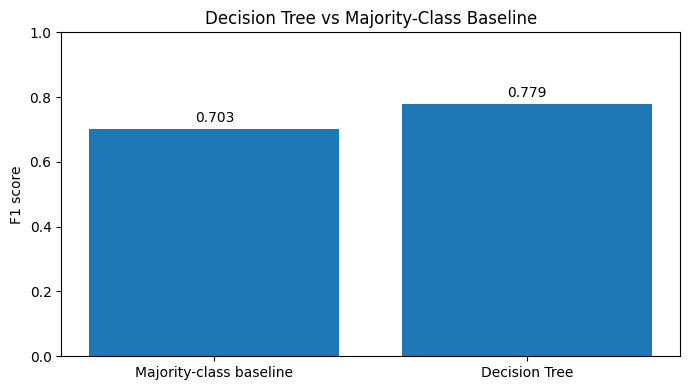

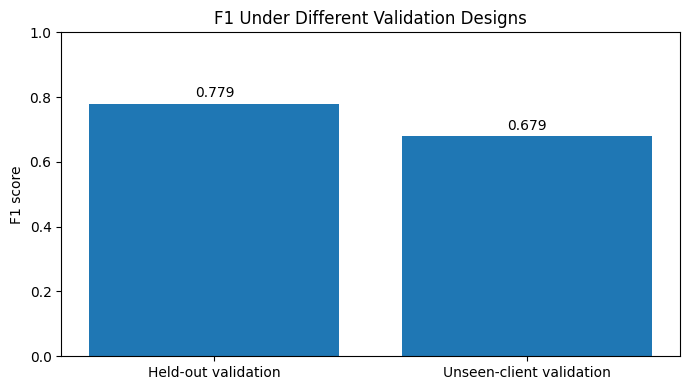

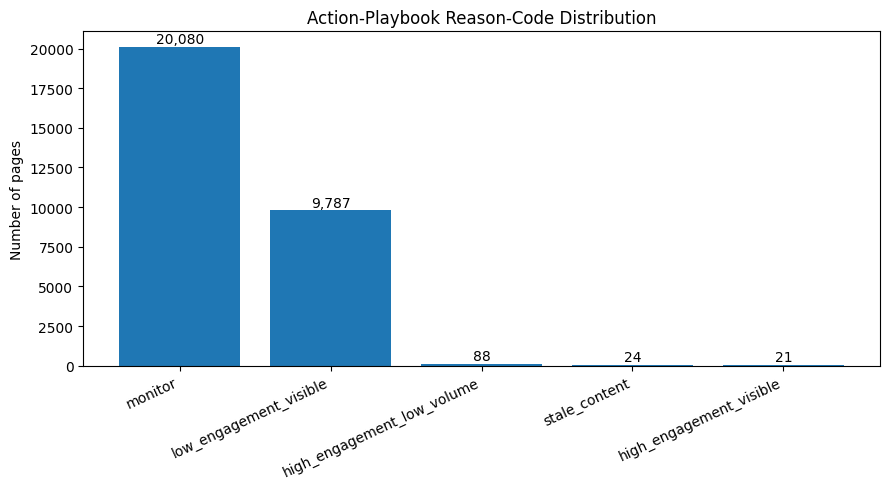

Paper results table


,evaluation,method,accuracy,precision,recall,f1
0,Held-out validation,Majority-class baseline,0.5420,0.5420,1.0000,0.7030
1,Held-out validation,Decision Tree,0.7393,0.7207,0.8475,0.7790
2,Unseen-client validation,Decision Tree,0.6565,0.6499,0.7104,0.6788



Saved paper artifacts:
- work/figures/capstone_model_vs_baseline_f1.png
- work/figures/capstone_generalization_f1.png
- work/figures/capstone_reason_code_distribution.png


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

FIGURES_DIR = Path("work/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Artifact 1 — Model vs baseline F1
model_results = pd.DataFrame([
    {
        "method": "Majority-class baseline",
        "f1": 0.702983
    },
    {
        "method": "Decision Tree",
        "f1": 0.778971
    }
])

plt.figure(figsize=(7, 4))

plt.bar(
    model_results["method"],
    model_results["f1"]
)

plt.ylabel("F1 score")
plt.title("Decision Tree vs Majority-Class Baseline")
plt.ylim(0, 1)

for i, value in enumerate(model_results["f1"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()

model_chart_path = FIGURES_DIR / "capstone_model_vs_baseline_f1.png"
plt.savefig(model_chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Artifact 2 — Generalization check
validation_results = pd.DataFrame([
    {
        "validation": "Held-out validation",
        "f1": 0.7790
    },
    {
        "validation": "Unseen-client validation",
        "f1": 0.6788
    }
])

plt.figure(figsize=(7, 4))

plt.bar(
    validation_results["validation"],
    validation_results["f1"]
)

plt.ylabel("F1 score")
plt.title("F1 Under Different Validation Designs")
plt.ylim(0, 1)

for i, value in enumerate(validation_results["f1"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()

generalization_chart_path = FIGURES_DIR / "capstone_generalization_f1.png"
plt.savefig(generalization_chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Artifact 3 — Action playbook distribution
reason_summary = pd.DataFrame([
    {
        "reason_code": "monitor",
        "pages": 20080,
        "share_pct": 66.93
    },
    {
        "reason_code": "low_engagement_visible",
        "pages": 9787,
        "share_pct": 32.62
    },
    {
        "reason_code": "high_engagement_low_volume",
        "pages": 88,
        "share_pct": 0.29
    },
    {
        "reason_code": "stale_content",
        "pages": 24,
        "share_pct": 0.08
    },
    {
        "reason_code": "high_engagement_visible",
        "pages": 21,
        "share_pct": 0.07
    }
])

plt.figure(figsize=(9, 5))

plt.bar(
    reason_summary["reason_code"],
    reason_summary["pages"]
)

plt.ylabel("Number of pages")
plt.title("Action-Playbook Reason-Code Distribution")
plt.xticks(rotation=25, ha="right")

for i, value in enumerate(reason_summary["pages"]):
    plt.text(i, value + 250, f"{value:,}", ha="center")

plt.tight_layout()

reason_chart_path = FIGURES_DIR / "capstone_reason_code_distribution.png"
plt.savefig(reason_chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Artifact 4 — Compact results table
results_table = pd.DataFrame([
    {
        "evaluation": "Held-out validation",
        "method": "Majority-class baseline",
        "accuracy": 0.5420,
        "precision": 0.5420,
        "recall": 1.0000,
        "f1": 0.7030
    },
    {
        "evaluation": "Held-out validation",
        "method": "Decision Tree",
        "accuracy": 0.7393,
        "precision": 0.7207,
        "recall": 0.8475,
        "f1": 0.7790
    },
    {
        "evaluation": "Unseen-client validation",
        "method": "Decision Tree",
        "accuracy": 0.6565,
        "precision": 0.6499,
        "recall": 0.7104,
        "f1": 0.6788
    }
])

print("Paper results table")

display(
    results_table.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}"
    })
)

print("\nSaved paper artifacts:")
print(f"- {model_chart_path}")
print(f"- {generalization_chart_path}")
print(f"- {reason_chart_path}")

## Reproducibility

The analysis is organized as a sequence of research and validation artifacts in the project repository.

- **Capstone notebook:** `work/notebooks/capstone.ipynb`
- **Validation notebook:** `work/notebooks/w06_validation_audit.ipynb`
- **Action-playbook outputs:** `work/outputs/`
- **Paper figures:** `work/figures/`
- **Source dataset:** `data/raw/content_refresh_anonymized.csv`

The analysis uses the public-safe, pseudonymized internship release described in this paper. The deployed paper excludes client names, private queries, and identifying information.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset — [FlyRank](https://flyrank.ai).

This work was completed as part of the FlyRank ML Internship and builds on the provided public-safe, pseudonymized content-refresh dataset and associated research workflow.

## Final public-safety and reproducibility check

Before deployment, confirm:

- [ ] No client names appear anywhere in the notebook or paper.
- [ ] No private search queries appear anywhere in the notebook or paper.
- [ ] No private/client-specific URLs are included.
- [ ] `trend_direction` and `trend_pct` are excluded from predictive features.
- [ ] Model results are clearly distinguished from heuristic action-playbook outputs.
- [ ] Causal claims are avoided.
- [ ] Held-out and unseen-client validation results are reported separately.
- [ ] The action queue is described as human-review decision support.
- [ ] No automated content-change capability is claimed.
- [ ] All paper figures are generated from reproducible notebook code.
- [ ] The repository and notebook paths are included for reproducibility.
- [ ] Data credit to FlyRank is included.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.